# Hyperparameters

In [10]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from scipy import sparse
import scanpy as sc
import matplotlib.pyplot as plt
import os
import rpy2.robjects as ro

from dotenv import load_dotenv; load_dotenv()


from utils import preprocessing
from utils import DEG

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ATTENTION: need for perpty of running jupternotbook
%matplotlib inline

PARALLEL_NEBULA_SCRIPT_PATH = os.getenv("PARALLEL_NEBULA_SCRIPT")

GENESET="001"
DATASET_FOLDER = f"/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_{GENESET}/depleted_versions"
TRUE_DEG_PATH = f"{DATASET_FOLDER}/../initial_perturbed/genes.csv"
QS_TMP_FOLDER = "/home/gdallagl/myworkdir/XDP/data/_old/nebula_tmp" # tmp folder where to save intemrediate results
METHOD_NAME = "cNMF_nebula"

# normalused version
HEALTHY_SPECTRA_FILE = "/home/gdallagl/myworkdir/data/XDP/artificial_bican/all_samples/depleted_dorsal_matrix/cNMF_healthy/bican_matrix_control_001.spectra.k_12.dt_0_05.consensus.txt"
ADATA_HEALTHY = "/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/all_samples/depleted_dorsal_matrix/depleted_dorsal_matrix_healthy.h5ad"
USAGES_HEALTHY_NORM = "/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/all_samples/depleted_dorsal_matrix/cNMF_healthy/bican_matrix_control_001.usages.k_12.dt_0_05.consensus_norm.txt"

# name of cell tyoe vauble annotaton to use in this analsys
CT_FOR_DEG_VARIABLE = "spn_type" #"Group_name",  "spn_type"
# name of Sample varibale
SAMPLE_VARIABLE = "donor_id"
# variable to test if differtially epxressed
CONTRAST_VARIABLE = "case_control"
# Level of contrat varibale to use as baseline
CONTRAST_BASELINE = "control"
# Level of contrat varibale to use as stimulated
CONTRAST_STIM = "case"

# Covariates to use for stat test
COVARIATES_FOR_DEG = ["Age.at.Death", "Sex", "PMI", "pct_mt", "pct_intronic",
                      ]
# libraru size col for  enbula
LIBRARY_SIZE_COL = "nCount_RNA"

# mitluple etst correction pvalue thr
ALPHA_MULTIPLE_TEST = 0.05
LOGFC_THR=0.1
PVAL_THR=0.05

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Calculate GEPs for Healhty --> Done indepently

the code to find GEPs and Usagpes for Helhty has been alredy done, we alredy have the results (for a specific K), in parclar:
- the usages for H (used as groud truth to test if our prohjection method is correcty)
- "spectra" = L1 normalised consensu program (ie the unitary directiosn where project the data)

As for PCA:
- the H projectiosn (GEP) are the same for all dtasets (Genesets and depletion %) --> H never chnages
- the D projections:
    - same IN HTE SAME GENESET (only chnage in % depeltion)

So we need to calculte the projection FOR THE CURRENT GENESET ONLY ONCE:
    - oen for all H (just chek if projection method produce same ruest of mode output)
    - one for all D (0% dpeletion) --> then we can just slice

In [15]:
GEPs_healthy_original = pd.read_csv(USAGES_HEALTHY_NORM)#GEPs == usages
GEPs_healthy_original

,Usage_1,Usage_2,Usage_3,Usage_4,Usage_5,Usage_6,Usage_7,Usage_8,Usage_9,Usage_10,Usage_11,Usage_12
0,0.017698,0.000000,0.009182,0.014204,0.056431,0.000000,0.000000,0.339537,0.100690,0.303274,0.000000,0.158984
1,0.000000,0.212019,0.024798,0.000000,0.093194,0.016783,0.019314,0.328565,0.063599,0.122677,0.011076,0.107975
2,0.194017,0.034872,0.001489,0.000000,0.047564,0.000000,0.000000,0.316759,0.252017,0.056980,0.042641,0.053663
3,0.000314,0.015867,0.001565,0.047198,0.013236,0.000000,0.068621,0.278224,0.033583,0.385470,0.000000,0.155922
4,0.008948,0.085958,0.006826,0.000000,0.022576,0.000000,0.218999,0.383851,0.000000,0.112258,0.007871,0.152713
...,...,...,...,...,...,...,...,...,...,...,...,...
65524,0.000000,0.044339,0.006834,0.031209,0.013090,0.138132,0.299033,0.374103,0.038129,0.047194,0.007936,0.000000
65525,0.000000,0.069918,0.019323,0.020196,0.000000,0.194010,0.072242,0.414117,0.089105,0.041061,0.080028,0.000000
65526,0.389632,0.000000,0.000000,0.000000,0.067893,0.224244,0.149074,0.169157,0.000000,0.000000,0.000000,0.000000
65527,0.004260,0.049722,0.001695,0.066912,0.000000,0.035663,0.051213,0.455828,0.064518,0.185720,0.084468,0.000000


In [ ]:
from scipy.optimize import nnls
from joblib import Parallel, delayed


# Read Healthy data
adata_healthy = sc.read_h5ad(ADATA_HEALTHY)
df_spectra = pd.read_csv(HEALTHY_SPECTRA_FILE, sep="\t", index_col=0)
cMNF_healthy_hvg = df_spectra.columns.to_list()
adata_healthy = adata_healthy[:, cMNF_healthy_hvg] # filter + reoder
assert list(df_spectra.columns) == list(adata_healthy.var_names)
healthy_stds = adata_healthy.X.toarray().std(axis=0)
GEPs_healthy_original = pd.read_csv(USAGES_HEALTHY_NORM)#GEPs == usages


# Read diseased data
dataset_0 = sorted(os.listdir(DATASET_FOLDER), reverse=False)[0]
dataset_path_h5ad_0_pct_depletion = os.path.join(DATASET_FOLDER, dataset_0, f"{dataset_0}.h5ad")
results_folder_0_pct_depletion = os.path.join(DATASET_FOLDER, dataset_0, METHOD_NAME)
os.makedirs(results_folder_0_pct_depletion, exist_ok=True)
adata = sc.read_h5ad(dataset_path_h5ad_0_pct_depletion, backed="r")
adata_diseased = adata[adata.obs[CONTRAST_VARIABLE] == CONTRAST_STIM].to_memory().copy()

def get_cNMF_projections(adata, reference_hvg, reference_gene_stds, df_spectra, normalize=True):
    
    # Subset to HVGs
    adata = adata[:, reference_hvg].copy()
    assert reference_hvg == list(adata_healthy.var_names)

    # Get raw counts
    if hasattr(adata.X, 'toarray'):
        X = adata.X.toarray()  # Convert sparse to dense
    else:
        X = adata.X
    
    # Variance normalize (match cNMF preprocessing)
    X_norm = X / reference_gene_stds[np.newaxis, :]

    # Convert spectra to numpy array
    spectra = df_spectra.values  # Shape: (K, H)

    # Inislize empty matirx for usages (NNLS fitted indpeelty)
    n_cells = X_norm.shape[0]
    n_programs = spectra.shape[0]
    usages = np.zeros((n_cells, n_programs))

    # Solve NNLS for each cell
    G = spectra.T 

    def solve_one(cell_expr):
        return nnls(G, cell_expr)[0]
    
    usages = np.array(
    Parallel(n_jobs=-1, backend="loky")(
        delayed(solve_one)(X_norm[i])
        for i in range(n_cells)
        )
    )
    

    # for i in range(n_cells):

    #     cell_expr = X_norm[i, :]
        
    #     # Solve: min ||cell_expr - spectra.T @ usage||² --< like LS y=Gu --> min |y-Gu|
    #     # Where spectra.T has shape (H, K)
    #     # and usage has shape (K,)
    #     usage, residual = nnls(G, cell_expr)
    #     usages[i, :] = usage
        
    #     if (i + 1) % 1000 == 0:
    #         print(f"Processed {i+1}/{n_cells} cells")

    # Normalize usages to sum to 1 per cell
    if normalize:
        row_sums = usages.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0  # Avoid division by zero
        usages = usages / row_sums

    # Add to adata
    gep_names = [f"GEP_{i+1}" for i in range(usages.shape[1])]
    usages_df = pd.DataFrame(
        usages,
        index=adata.obs_names,   # ensures correct cell alignment
        columns=gep_names
    )
    adata.obs[gep_names] = usages_df
    
    return usages, adata


GEPs_healthy_new, adata_healthy_GEP = get_cNMF_projections(adata_healthy, cMNF_healthy_hvg, healthy_stds, df_spectra, normalize=True)
GEPs_diseased, adata_diseased_GEP = get_cNMF_projections(adata_diseased, cMNF_healthy_hvg, healthy_stds, df_spectra, normalize=True)


Processed 1000/65529 cells
Processed 2000/65529 cells
Processed 3000/65529 cells
Processed 4000/65529 cells
Processed 5000/65529 cells
Processed 6000/65529 cells
Processed 7000/65529 cells
Processed 8000/65529 cells
Processed 9000/65529 cells
Processed 10000/65529 cells
Processed 11000/65529 cells
Processed 12000/65529 cells
Processed 13000/65529 cells
Processed 14000/65529 cells
Processed 15000/65529 cells
Processed 16000/65529 cells
Processed 17000/65529 cells
Processed 18000/65529 cells
Processed 19000/65529 cells
Processed 20000/65529 cells
Processed 21000/65529 cells
Processed 22000/65529 cells
Processed 23000/65529 cells
Processed 24000/65529 cells
Processed 25000/65529 cells
Processed 26000/65529 cells
Processed 27000/65529 cells
Processed 28000/65529 cells
Processed 29000/65529 cells
Processed 30000/65529 cells
Processed 31000/65529 cells
Processed 32000/65529 cells
Processed 33000/65529 cells
Processed 34000/65529 cells
Processed 35000/65529 cells
Processed 36000/65529 cells
P

In [48]:
# Chekc if projection is good (differc eorianlusages helahty an new claulted
frob_norm = np.linalg.norm(GEPs_healthy_original-GEPs_healthy_new, ord='fro')
print(f"Frob Norm: {frob_norm:.6f}")
rmse = np.sqrt(np.mean((GEPs_healthy_original - GEPs_healthy_new)**2))
print(f"RMSE: {rmse:.6f}")
overall_corr = np.corrcoef(GEPs_healthy_original.values.flatten(), GEPs_healthy_new.flatten())#[0, 1]
overall_corr
# print(f"\nOverall correlation: {overall_corr:.4f}")

Frob Norm: 0.064152
RMSE: 0.000072


array([[1.        , 0.99999979],
       [0.99999979, 1.        ]])

In [54]:
correlations = []
from scipy.stats import pearsonr
for i in range(GEPs_healthy_original.shape[1]):  # For each program
    corr, _ = pearsonr(GEPs_healthy_original.values[:, i], GEPs_healthy_new[:, i])
    correlations.append(corr)
    print(f"Program {i+1}: r = {corr}")

Program 1: r = 0.9999999561617015
Program 2: r = 0.9999996810734618
Program 3: r = 0.9999999918648432
Program 4: r = 0.9999998095286777
Program 5: r = 0.9999999849496437
Program 6: r = 0.9999992987013266
Program 7: r = 0.9999999491192717
Program 8: r = 0.9999998106614552
Program 9: r = 0.9999999526061916
Program 10: r = 0.9999996799946569
Program 11: r = 0.9999992991956976
Program 12: r = 0.9999987216375019


In [42]:
# Explore df
adata = sc.concat([adata_healthy_GEP, adata_diseased_GEP], axis=0)
GEPs = [i for i in adata.obs.columns.tolist() if "GEP_" in i]
df_cov = adata.obs[GEPs].reset_index().rename(columns={"index":"barcode"})
#df_cov.to_csv(f"{results_folder_0_pct_depletion}/covariates_df.csv", index=False)
df_cov

,barcode,GEP_1,GEP_2,GEP_3,GEP_4,GEP_5,GEP_6,GEP_7,GEP_8,GEP_9,GEP_10,GEP_11,GEP_12
0,STR_D1_Matrix_MSN_s5_s5_AACAGGAGTGCACGTA_1,0.017698,0.000000,0.009182,0.014204,0.056431,0.000000,0.000000,0.339536,0.100690,0.303275,0.000000,0.158984
1,STR_D1_Matrix_MSN_s5_s5_ACATTGGTCGGGTATC_1,0.000000,0.212084,0.024802,0.000000,0.093204,0.016644,0.019229,0.328446,0.063556,0.122690,0.011153,0.108191
2,STR_D1_Matrix_MSN_s5_s5_ATTGCATAGACCAATT_1,0.194010,0.034875,0.001489,0.000000,0.047563,0.000000,0.000000,0.316779,0.252021,0.056982,0.042630,0.053652
3,STR_D1_Matrix_MSN_s5_s5_CGGATATGTCTCGATC_1,0.000285,0.015890,0.001553,0.047231,0.013252,0.000000,0.068724,0.278299,0.033606,0.385339,0.000000,0.155822
4,STR_D1_Matrix_MSN_s5_s5_ACCATTCTCCAGTATG_1,0.008940,0.085976,0.006827,0.000000,0.022578,0.000000,0.219040,0.383889,0.000000,0.112237,0.007836,0.152677
...,...,...,...,...,...,...,...,...,...,...,...,...,...
121628,s38_2025-06-04_s38_GEX_CAP_rxn4_AGTCCGGTCCGACTAA,0.048619,0.039837,0.261692,0.043492,0.000000,0.000000,0.042770,0.124389,0.291996,0.025568,0.121636,0.000000
121629,s38_2025-06-04_s38_GEX_CAP_rxn4_ACATAGAAGATATTGC,0.085489,0.155269,0.106606,0.021194,0.013238,0.000000,0.000000,0.203121,0.101460,0.143069,0.170553,0.000000
121630,s38_2025-06-04_s38_GEX_CAP_rxn4_CGTTTCAGTCTGTATT,0.058746,0.096533,0.383648,0.000000,0.083583,0.000000,0.057064,0.280774,0.000000,0.000000,0.039652,0.000000
121631,s38_2025-06-04_s38_GEX_CAP_rxn4_ACGTCCGAGCTGGCAT,0.041859,0.111086,0.056899,0.088057,0.015100,0.000000,0.036590,0.267369,0.168081,0.009215,0.205744,0.000000


In [44]:

sc.pp.normalize_total(adata, target_sum=1e4, inplace=True)
sc.pp.log1p(adata)
sc.pp.scale(adata, max_value=10) #z-score normalization
sc.tl.pca(adata, svd_solver='arpack', n_comps=50)
sc.pp.neighbors(adata, use_rep='X_pca', n_pcs=30) # from X_pca
sc.tl.umap(adata) # uese neighbors

/home/gdallagl/.pyenv/versions/3.11.8/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


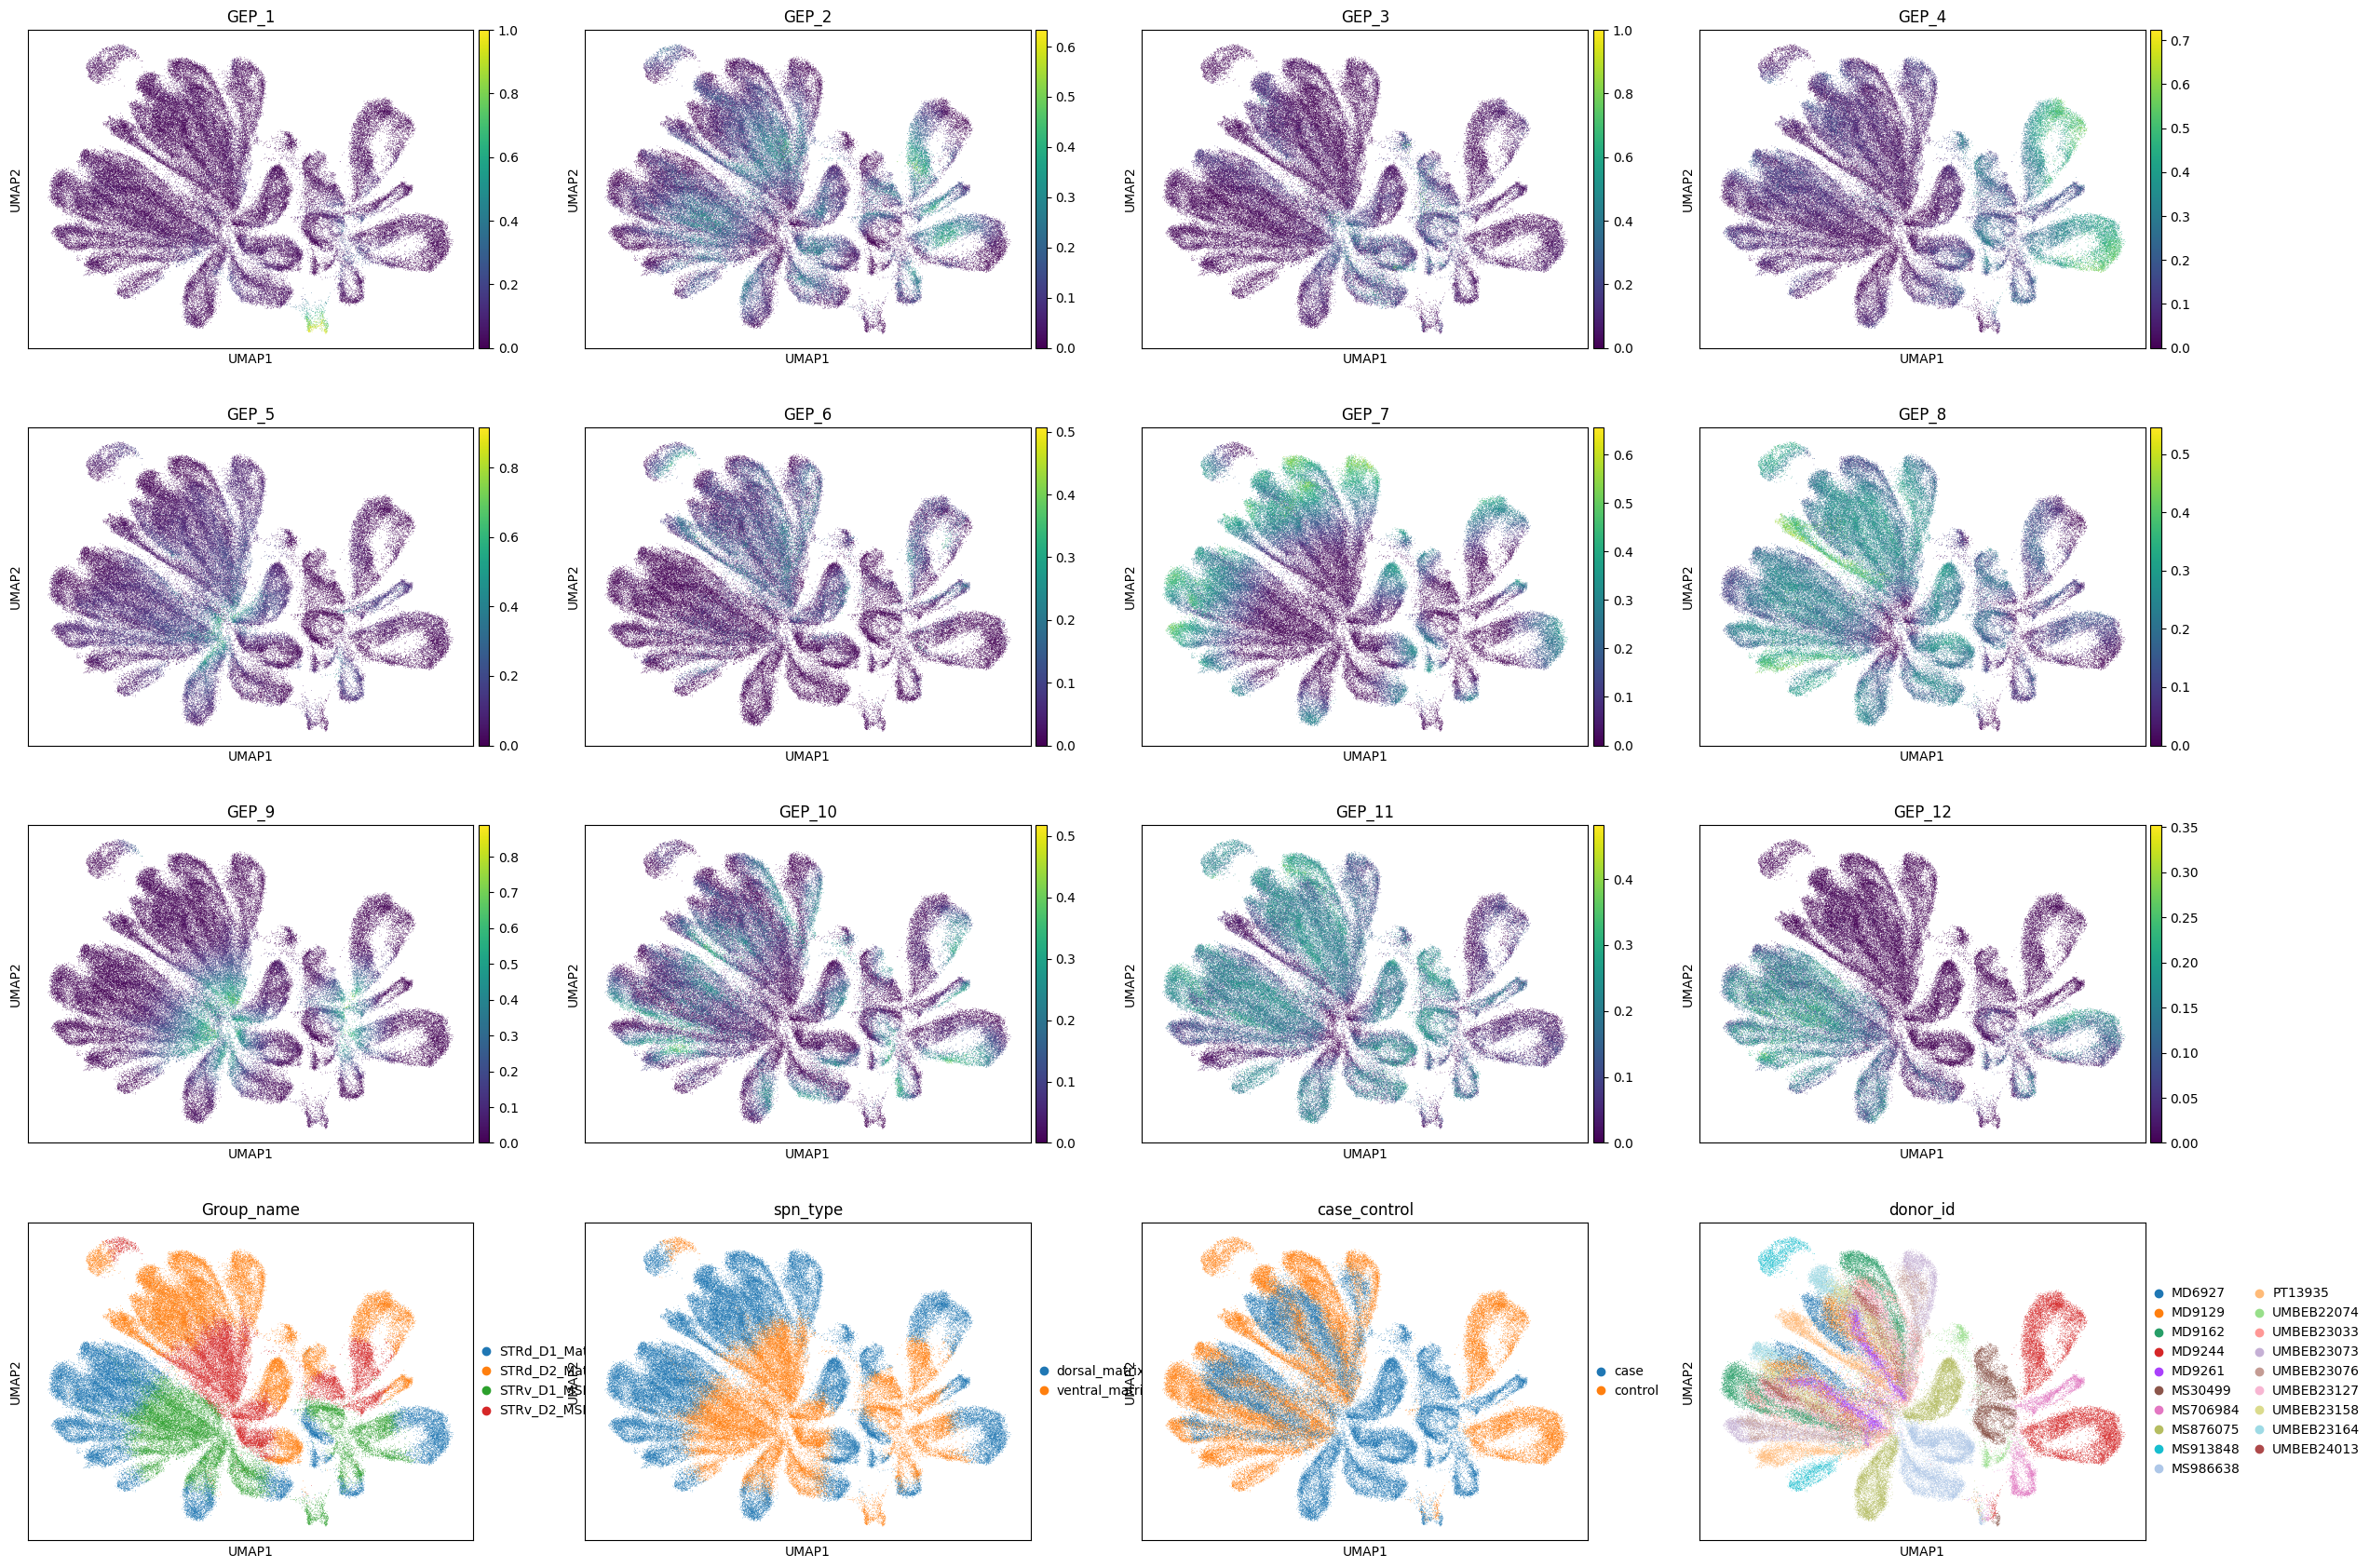

In [45]:
sc.pl.umap(adata, color=[*GEPs, "Group_name", "spn_type", CONTRAST_VARIABLE, SAMPLE_VARIABLE])

~ case_control + GEP_1 + GEP_2 + GEP_3 + GEP_4 + GEP_5 + GEP_6 + GEP_7 + GEP_8 + GEP_9 + GEP_10 + GEP_11 + GEP_12 + Q("Age.at.Death") + Sex + PMI + pct_mt + pct_intronic


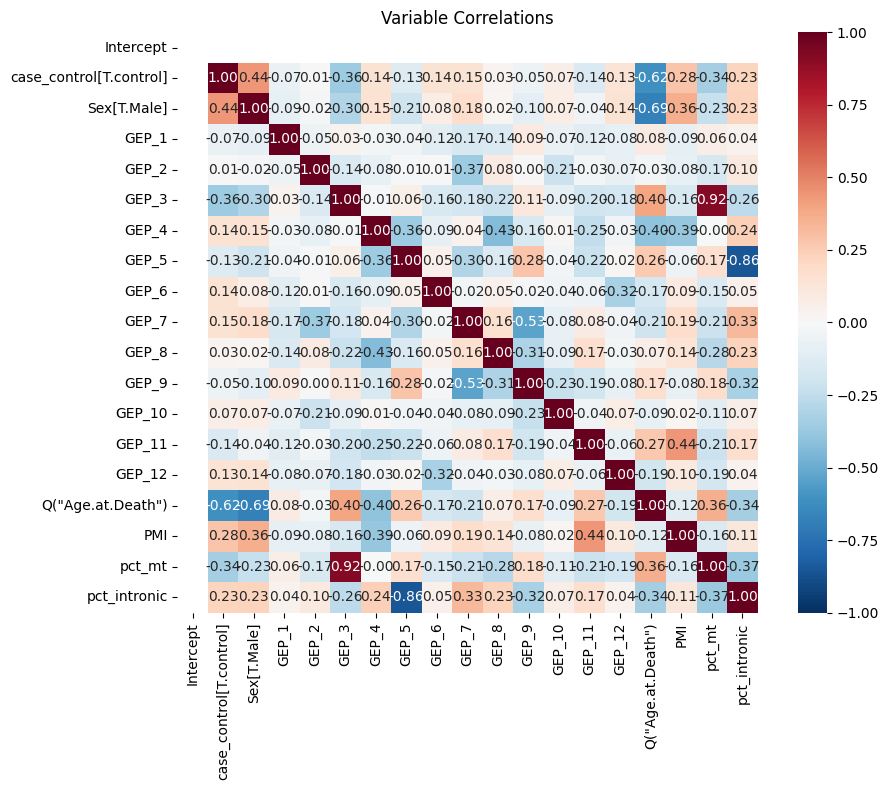

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                   variable       VIF
5                     GEP_3       inf
4                     GEP_2       inf
3                     GEP_1       inf
11                    GEP_9       inf
12                   GEP_10       inf
13                   GEP_11       inf
6                     GEP_4       inf
7                     GEP_5       inf
8                     GEP_6       inf
9                     GEP_7       inf
10                    GEP_8       inf
14                   GEP_12       inf
17                   pct_mt  7.958004
18             pct_intronic  5.380411
15        Q("Age.at.Death")  3.862292
2               Sex[T.Male]  2.368207
16                      PMI  2.193720
1   case_control[T.control]  1.857544
0                 Intercept  0.000000

binary identifiability test. True


In [46]:
# Check collinarity
if True:
    DEG.check_corr_cov_in_design(adata, vars_in_formula=[CONTRAST_VARIABLE, *GEPs, *COVARIATES_FOR_DEG], corr_thr=0.7, split=" + ")


# Create Covs and update .qs File

Each method will add its covaritates in .qs obj (needed for Nebula).

In [ ]:
for dataset in sorted(os.listdir(DATASET_FOLDER), reverse=True):

    print(f"\n######\n Processing dataset: {dataset} \n######\n")

    dataset_path_h5ad = os.path.join(DATASET_FOLDER, dataset, f"{dataset}.h5ad")
    dataset_path_qs = os.path.join(DATASET_FOLDER, dataset, f"{dataset}.qs")

    results_folder = os.path.join(DATASET_FOLDER, dataset, METHOD_NAME)
    cov_df_csv_path = f"{results_folder_0_pct_depletion}/covariates_df.csv"
    os.makedirs(results_folder, exist_ok=True)

    ###################

    ### Logic to calcualte specific Covs --> df with covariates (cov_df_csv_path)

    # # PCs for H and D alredy caluted before
    #     # for H --> same for every geenset
    #     # for D --> changes depnding of geneset

    # # SUBSET SIGNIFICANT PCs
    # adata = sc.read_h5ad(dataset_path_h5ad)
    # df_pcs_0_pct = pd.read_csv(f"{results_folder_0_pct_depletion}/pcs_all.csv")
    # df_pcs_0_pct = df_pcs_0_pct.merge(
    #     adata.obs[[CONTRAST_VARIABLE, *COVARIATES_FOR_DEG, SAMPLE_VARIABLE]], 
    #     left_on="barcode", right_index=True, 
    #     how="right" # ONLY cells in current dataset
    # ).drop(columns=["barcode"])

    # display(df_pcs_0_pct)

    # #"Does this PC differ between healthy and diseased, controlling for other covariates?"
    # pcs_vars = [col for col in df_pcs_0_pct.columns.tolist() if col.startswith('PC_')]
    # df_test, pcs_sig = test_significant_pcs(
    #     df_cov=df_pcs_0_pct, 
    #     contrast_var = CONTRAST_VARIABLE,
    #     donor_var = SAMPLE_VARIABLE,
    #     pcs_vars=pcs_vars,
    #     covs = COVARIATES_FOR_DEG,
    # )

    # Save df with PCs of H+D of CURRENT dataset
    pcs_sig = ["PC_1", "PC_2"]
    df_pcs_all = pd.read_csv(f"{results_folder_0_pct_depletion}/pcs_all.csv") # OF THIS SPECIFIC GENESET
    col_to_retain = ["barcode", *pcs_sig] # SELECT ONYL SIGNIFICANT PCs
    df_pcs_all = df_pcs_all[col_to_retain]
    df_pcs_all.to_csv(cov_df_csv_path, index=False)

    ##################

    # preprocessing.add_metadata_to_qs(
    #     dataset_path_h5ad, cov_df_csv_path, file_type="h5ad", 
    #     col_name_contain="PC_", barcode_col="barcode")
    # preprocessing.add_metadata_to_qs(
    #     dataset_path_qs, cov_df_csv_path, file_type="qs", 
    #     col_name_contain="PC_", barcode_col="barcode")

    break


######
 Processing dataset: depleted_0.80_dorsal_matrix 
######



,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,case_control,Age.at.Death,Sex,PMI,pct_mt,pct_intronic,donor_id
0,-6.213700,0.132101,-8.641293,-5.980516,-0.511495,-1.002206,control,44,Male,6,0.0017,0.6935,PT13935
1,-6.716314,-2.113154,-4.188440,-4.875260,-1.423366,0.891863,control,44,Male,6,0.0029,0.6786,PT13935
2,-15.507102,3.968190,-6.856667,-4.131546,12.471243,-1.419597,control,44,Male,6,0.0015,0.6857,PT13935
3,1.497176,-1.518240,-7.488803,-6.552142,-0.778984,0.118711,control,44,Male,6,0.0006,0.7213,PT13935
4,4.384337,-3.285637,-6.697863,-5.775413,0.760190,-1.664799,control,44,Male,6,0.0011,0.7234,PT13935
...,...,...,...,...,...,...,...,...,...,...,...,...,...
121587,-35.493390,-19.130931,7.540395,20.204888,-0.655269,9.426783,case,88,Female,7,0.0182,0.4678,MS986638
121608,-22.138411,9.275656,6.249264,4.362751,8.491911,-3.026628,case,88,Female,7,0.0091,0.6918,MS986638
121612,-16.724607,8.885364,5.455495,-3.836130,8.938383,2.071619,case,88,Female,7,0.0018,0.6907,MS986638
121615,-19.060598,1.613405,5.604657,10.148918,0.913466,1.342479,case,88,Female,7,0.0257,0.6507,MS986638



Testing: PC_1 ~ case_control + Q("Age.at.Death") + Sex + PMI + pct_mt + pct_intronic


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the e

  ✓ coef=-15.6292, SE=nan, p=nan, converged=True

Testing: PC_2 ~ case_control + Q("Age.at.Death") + Sex + PMI + pct_mt + pct_intronic
  ✓ coef=-4.4616, SE=2.6284, p=8.9608e-02, converged=True

Testing: PC_3 ~ case_control + Q("Age.at.Death") + Sex + PMI + pct_mt + pct_intronic


...

  ✓ coef=5.6527, SE=nan, p=nan, converged=True

Testing: PC_5 ~ case_control + Q("Age.at.Death") + Sex + PMI + pct_mt + pct_intronic


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the e

  ✓ coef=-4.1552, SE=nan, p=nan, converged=True

Testing: PC_6 ~ case_control + Q("Age.at.Death") + Sex + PMI + pct_mt + pct_intronic


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the e

  ✓ coef=1.2068, SE=nan, p=nan, converged=True

RESULTS
Tested: 6 PCs
Converged: 6
Significant (FDR<0.05): 0
Significant PCs: []


# DEG

In [ ]:
for dataset in sorted(os.listdir(DATASET_FOLDER), reverse=True):

    #dataset="depleted_0.05_dorsal_matrix"

    print(f"\n######\n Processing dataset: {dataset} \n######\n")

    results_folder = os.path.join(DATASET_FOLDER, dataset, METHOD_NAME)
    dataset_path_qs = os.path.join(DATASET_FOLDER, dataset, f"{dataset}.qs")
    save_csv_path = os.path.join(results_folder, f"{dataset}-{METHOD_NAME}_results.csv")
    print(save_csv_path)

    # Define PCs cov
    pcs = [f'PC_{i+1}' for i in range(N_PCS_TO_USE)]

    # Run Nebula
    nebula_result_path = DEG.run_nebula_parallel_script(
        path_qs = dataset_path_qs,
        path_nebula_script = PARALLEL_NEBULA_SCRIPT_PATH,
        id_col = SAMPLE_VARIABLE,
        covs = [CONTRAST_VARIABLE, *COVARIATES_FOR_DEG, *pcs], # wihtout LIBRARY_SIZE_COL, with constrst vaibale too
        offset_col = LIBRARY_SIZE_COL,
        n_folds = 30, # (MORE gene chunks = LESS RAM per chunk)
        n_cores = 15, # (FEWER parallel jobs = LESS total RAM)
        save_tmp = False,
        suffix = None,
    )

    # save csv
    ro.r(f'''
        library(qs)
        obj <- qread("{nebula_result_path}")
        df <- obj$summary
        write.csv(df, "{save_csv_path}", row.names = FALSE)
    ''')

    #break

    


######
 Processing dataset: depleted_0.80_dorsal_matrix 
######

/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_003/depleted_versions/depleted_0.80_dorsal_matrix/PCA_nebula/depleted_0.80_dorsal_matrix-PCA_nebula_results.csv
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_003/depleted_versions/depleted_0.80_dorsal_matrix/depleted_0.80_dorsal_matrix.qs --id-col donor_id --offset-col nCount_RNA --n-folds 30 --n-cores 20 --save-tmp 0 --covs case_control,Age.at.Death,Sex,PMI,pct_mt,pct_intronic,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6
[INFO] Input: /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_003/depleted_versions/depleted_0.80_dorsal_matrix/depleted_0.80_dorsal_matrix.qs
[INFO] Script dir: /home/gdallagl/myworkdir/XDP/utils/nebula_scripts
[INFO] Base name: depleted_0.80_dorsal_matrix.qs
[INFO] Geneset dir: /home/gdallagl/myworkdir/data/XDP/artificial_

***** LOADING sobj: /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_003/depleted_versions/depleted_0.80_dorsal_matrix/depleted_0.80_dorsal_matrix.qs
Splitting 37905 genes into 30 chunks
Wrote /home/gdallagl/myworkdir/data/XDP/artificial_bican/geneset_003/depleted_versions/depleted_0.80_dorsal_matrix/depleted_0.80_dorsal_matrix__nebula_ln/chunks/chunk_001_of_030.qs (genes 1 --> 1264; nGenes=1264)
Wrote /home/gdallagl/myworkdir/data/XDP/artificial_bican/geneset_003/depleted_versions/depleted_0.80_dorsal_matrix/depleted_0.80_dorsal_matrix__nebula_ln/chunks/chunk_002_of_030.qs (genes 1265 --> 2528; nGenes=1264)
Wrote /home/gdallagl/myworkdir/data/XDP/artificial_bican/geneset_003/depleted_versions/depleted_0.80_dorsal_matrix/depleted_0.80_dorsal_matrix__nebula_ln/chunks/chunk_003_of_030.qs (genes 2529 --> 3792; nGenes=1264)
Wrote /home/gdallagl/myworkdir/data/XDP/artificial_bican/geneset_003/depleted_versions/depleted_0.80_dorsal_matrix/depleted_0.80_dorsal_matrix__nebula_ln/

KeyboardInterrupt: 

# Plot Results

In [7]:
df_true_degs = pd.read_csv(TRUE_DEG_PATH)
df_true_degs


,gene_id,log2fc,frac_applied,n_subjects_applied,subjects_applied
0,ENSG00000237280,0.522222,0.3,3,"MD9129,MS986638,UMBEB23076"
1,ENSG00000250027,0.733333,0.7,7,"MD9129,MS30499,MS706984,MS876075,MS986638,UMBE..."
2,ENSG00000289321,-0.733333,0.4,4,"MD6927,MS30499,MS876075,MS986638"
3,OTULIN,0.100000,0.6,6,"MD6927,MD9129,MS30499,MS876075,MS986638,UMBEB2..."
4,MYLIP,-0.522222,0.2,2,"MD6927,UMBEB22074"
...,...,...,...,...,...
395,FLVCR2,0.733333,0.1,1,UMBEB23158
396,PTPN20,1.577778,0.5,5,"MD6927,MS30499,MS706984,UMBEB22074,UMBEB23158"
397,RACGAP1,-0.100000,0.7,7,"MD6927,MD9129,MS30499,UMBEB22074,UMBEB23076,UM..."
398,ENSG00000257239,2.000000,0.5,5,"MS706984,MS876075,MS986638,UMBEB23076,UMBEB24013"



######
 Processing dataset: depleted_0.00_dorsal_matrix 
######



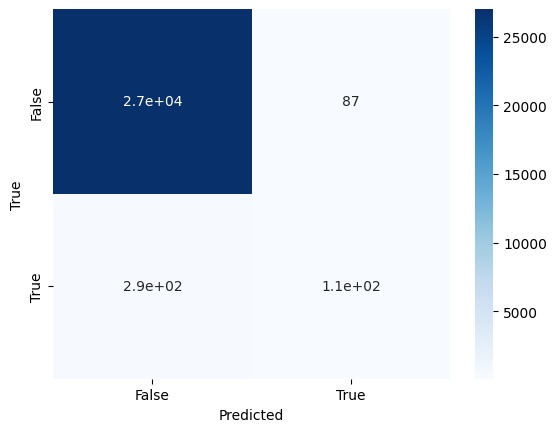

Precision: 0.563
Recall:    0.280
F1 Score:  0.374
Accuracy:  0.986
Clipping 21 genes with -log10(p) > 10


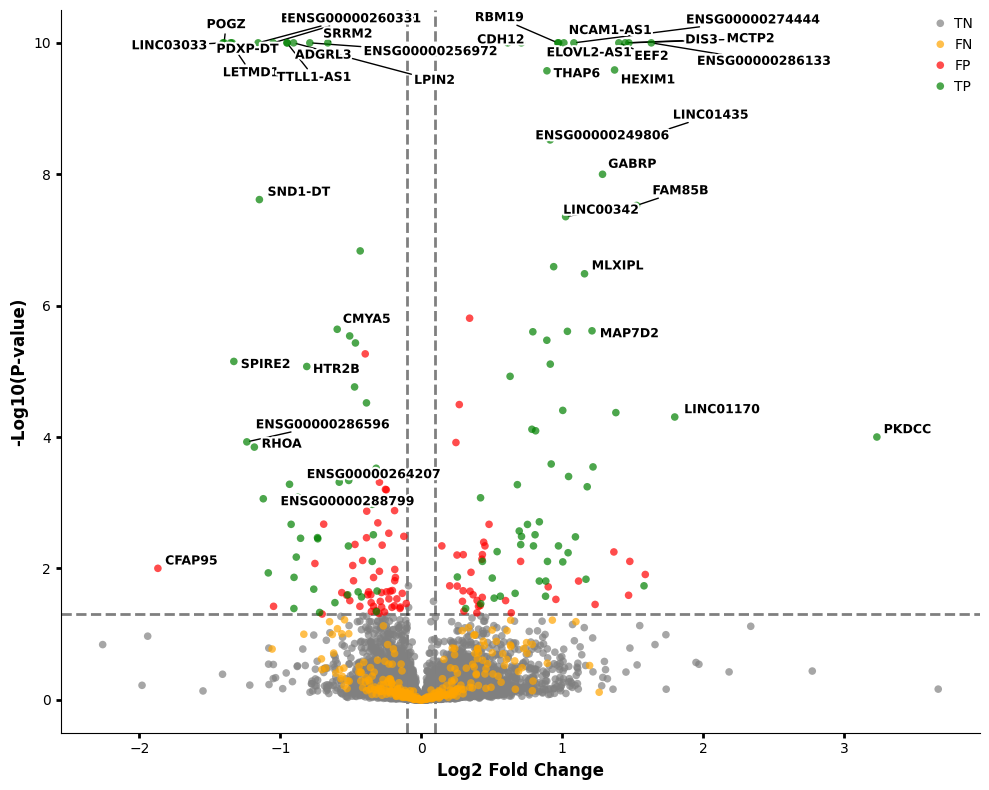

,gene,logFC_case_controlcase,p_case_controlcase,adj_p_case_controlcase,is_significant,is_true_DEG,-log10p,category,sorter
0,A1BG,-0.117213,0.001793,0.133972,False,False,0.872987,TN,-0.102325
1,A1BG-AS1,-0.071951,0.281968,0.819951,False,False,0.086212,TN,-0.006203
2,A1CF,-0.217860,0.025654,0.457762,False,False,0.339360,TN,-0.073933
3,A2M,0.325186,0.149773,0.730648,False,False,0.136292,TN,0.044320
4,A2M-AS1,0.023495,0.696624,0.949352,False,False,0.022573,TN,0.000530
...,...,...,...,...,...,...,...,...,...
27476,ZZEF1,-0.032563,0.196009,0.767911,False,False,0.114689,TN,-0.003735
27477,ZZZ3,0.045020,0.296227,0.827682,False,False,0.082137,TN,0.003698
27478,ENSG00000205653,0.485690,0.471350,0.891927,False,False,0.049671,TN,0.024125
27479,ENSG00000223438,-0.030626,0.960335,0.994888,False,False,0.002226,TN,-0.000068


In [8]:
for dataset in sorted(os.listdir(DATASET_FOLDER)):

    print(f"\n######\n Processing dataset: {dataset} \n######\n")

    results_folder = os.path.join(DATASET_FOLDER, dataset, METHOD_NAME)
    save_csv_path = os.path.join(results_folder, f"{dataset}-{METHOD_NAME}_results.csv")

    df_nebula = pd.read_csv(save_csv_path)

    DEG.plot_nebula_results(df_nebula, 
                    df_true_degs, 
                    col_p=f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}", 
                    col_logFC=f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}", 
                    col_gene="gene",
                    PVAL_THR=PVAL_THR,
                    LOGFC_THR=LOGFC_THR,
                    max_FDR=10,
                    add_adj_p_col=True
                    )
    break